In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Setup device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# Transformations applied on each image
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize the images
])

# Load the dataset
train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=1000, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Define the CNN model
class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),  # Input: 1 x 28 x 28, Output: 64 x 28 x 28
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))  # Output: 64 x 14 x 14

        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),  # Output: 64 x 12 x 12
            nn.ReLU(),
            nn.MaxPool2d(2))  # Output: 64 x 6 x 6

        self.fc1 = nn.Linear(64 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)  # 10 classes

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.view(out.size(0), -1)  # Flatten the output
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instantiate the model, loss function, and optimizer
model = FashionCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Function to train the model
def train(epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
    print(f'Train Epoch: {epoch} -- Loss: {loss.item():.6f}')

# Training the model
for epoch in range(1, 15):  # Train for 15 epochs
    train(epoch)


# Evaluation
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Accuracy of the network on the 10000 test images: {100 * correct / total}%')

Using device: mps
Train Epoch: 1 -- Loss: 0.493038
Train Epoch: 2 -- Loss: 0.383282
Train Epoch: 3 -- Loss: 0.335266
Train Epoch: 4 -- Loss: 0.329012
Train Epoch: 5 -- Loss: 0.284194
Train Epoch: 6 -- Loss: 0.314874
Train Epoch: 7 -- Loss: 0.284091
Train Epoch: 8 -- Loss: 0.254676
Train Epoch: 9 -- Loss: 0.240069
Train Epoch: 10 -- Loss: 0.258137
Train Epoch: 11 -- Loss: 0.204969
Train Epoch: 12 -- Loss: 0.240029
Train Epoch: 13 -- Loss: 0.215590
Train Epoch: 14 -- Loss: 0.207185
Accuracy of the network on the 10000 test images: 90.84%


In [2]:
from torchsummary import summary
model = FashionCNN()
summary(model, input_size=(1, 28, 28)) # (Channels, Height, Width)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]             640
              ReLU-2           [-1, 64, 28, 28]               0
         MaxPool2d-3           [-1, 64, 14, 14]               0
            Conv2d-4           [-1, 64, 12, 12]          36,928
              ReLU-5           [-1, 64, 12, 12]               0
         MaxPool2d-6             [-1, 64, 6, 6]               0
            Linear-7                  [-1, 128]         295,040
            Linear-8                   [-1, 10]           1,290
Total params: 333,898
Trainable params: 333,898
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 1.02
Params size (MB): 1.27
Estimated Total Size (MB): 2.30
----------------------------------------------------------------


In [30]:
import urllib
import zipfile

url = "https://storage.googleapis.com/learning-datasets/horse-or-human.zip"

file_name = "horse-or-human.zip"
training_dir = 'horse-or-human/training/'
urllib.request.urlretrieve(url, file_name)

zip_ref = zipfile.ZipFile(file_name, 'r')
zip_ref.extractall(training_dir)
zip_ref.close()

url = "https://storage.googleapis.com/learning-datasets/validation-horse-or-human.zip"
file_name = "validation-horse-or-human.zip"
validation_dir = 'horse-or-human/validation/'
urllib.request.urlretrieve(url, file_name)

zip_ref = zipfile.ZipFile(file_name, 'r')
zip_ref.extractall(validation_dir)
zip_ref.close()

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations
transform = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the datasets
train_dataset = datasets.ImageFolder(root=training_dir,
                                     transform=transform)
val_dataset = datasets.ImageFolder(root=validation_dir,
                                   transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

class HorsesHumansCNN(nn.Module):
    def __init__(self):
        super(HorsesHumansCNN, self).__init__()
        # using 3 for the input channels as images are RGB
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)  # Input: 3 x 150 x 150, Output: 16 x 150 x 150
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # Output: 32 x 75 x 75
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Output: 64 x 75 x 75
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 18 * 18, 512) # Adjusted for 150x150 input
        self.drop = nn.Dropout(0.25) # Dropout layer for regularization
        self.fc2 = nn.Linear(512, 1)  # Binary classification
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(-1, 64 * 18 * 18)
        x = F.relu(self.fc1(x))
        x = self.drop(x)  # Apply dropout
        x = self.fc2(x)
        x = torch.sigmoid(x)  # Use sigmoid to output probabilities
        return x

In [6]:
from torchsummary import summary

model = HorsesHumansCNN()
summary(model, input_size=(3, 150, 150))  # (Channels, Height, Width)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 150, 150]             448
         MaxPool2d-2           [-1, 16, 75, 75]               0
            Conv2d-3           [-1, 32, 75, 75]           4,640
         MaxPool2d-4           [-1, 32, 37, 37]               0
            Conv2d-5           [-1, 64, 37, 37]          18,496
         MaxPool2d-6           [-1, 64, 18, 18]               0
            Linear-7                  [-1, 512]      10,617,344
           Dropout-8                  [-1, 512]               0
            Linear-9                    [-1, 1]             513
Total params: 10,641,441
Trainable params: 10,641,441
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.26
Forward/backward pass size (MB): 5.98
Params size (MB): 40.59
Estimated Total Size (MB): 46.83
-----------------------------------

In [7]:
# Define the loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

def train_model(num_epochs, train_loader=train_loader, val_loader=val_loader):
    model.to(device)
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).float()
            optimizer.zero_grad()
            outputs = model(images).view(-1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_train_loss = running_loss / len(train_loader)
        print(f'Epoch {epoch + 1}, Loss: {running_loss / len(train_loader):.4f}')

        # Evaluate on training set
        # model.eval()
        # with torch.no_grad():
        #     correct = 0
        #     total = 0
        #     for images, labels in train_loader:
        #         images, labels = images.to(device), labels.to(device).float()
        #         outputs = model(images).view(-1)
        #         predicted = outputs > 0.5 # Threshold predictions
        #         total += labels.size(0)
        #         correct += (predicted == labels).sum().item()
        #     print(f'Test Set Accuracy: {100 * correct / total:.2f}%')
        
        # Evaluate on validation set
        model.eval()
        val_running_loss = 0.0
        with torch.no_grad():
            correct = 0
            total = 0
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).float()
                outputs = model(images).view(-1)
                predicted = outputs > 0.5 # Threshold predictions
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
                vloss = criterion(outputs, labels)
                val_running_loss += vloss.item()
            print(f'Validation Set Accuracy: {100 * correct / total:.2f}%')
        epoch_val_loss = val_running_loss / len(val_loader)
        
        print(f'Epoch {epoch + 1}, Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}')
        
        # append loss of each epoch to the loss tracker
        train_losses.append(epoch_train_loss)
        val_losses.append(epoch_val_loss)
    
    return train_losses, val_losses

    

model_train_loss, model_val_loss = train_model(num_epochs=50)

Epoch 1, Loss: 0.6108
Validation Set Accuracy: 86.33%
Epoch 1, Train Loss: 0.6108 | Val Loss: 0.3780
Epoch 2, Loss: 0.2942
Validation Set Accuracy: 82.03%
Epoch 2, Train Loss: 0.2942 | Val Loss: 0.7525
Epoch 3, Loss: 0.0740
Validation Set Accuracy: 82.03%
Epoch 3, Train Loss: 0.0740 | Val Loss: 1.2017
Epoch 4, Loss: 0.0475
Validation Set Accuracy: 83.59%
Epoch 4, Train Loss: 0.0475 | Val Loss: 1.1664
Epoch 5, Loss: 0.0199
Validation Set Accuracy: 89.06%
Epoch 5, Train Loss: 0.0199 | Val Loss: 1.1265
Epoch 6, Loss: 0.0102
Validation Set Accuracy: 77.34%
Epoch 6, Train Loss: 0.0102 | Val Loss: 5.2840
Epoch 7, Loss: 0.0030
Validation Set Accuracy: 85.94%
Epoch 7, Train Loss: 0.0030 | Val Loss: 3.3317
Epoch 8, Loss: 0.0010
Validation Set Accuracy: 83.59%
Epoch 8, Train Loss: 0.0010 | Val Loss: 5.9769
Epoch 9, Loss: 0.0014
Validation Set Accuracy: 83.20%
Epoch 9, Train Loss: 0.0014 | Val Loss: 6.3337
Epoch 10, Loss: 0.0120
Validation Set Accuracy: 79.30%
Epoch 10, Train Loss: 0.0120 | Val L

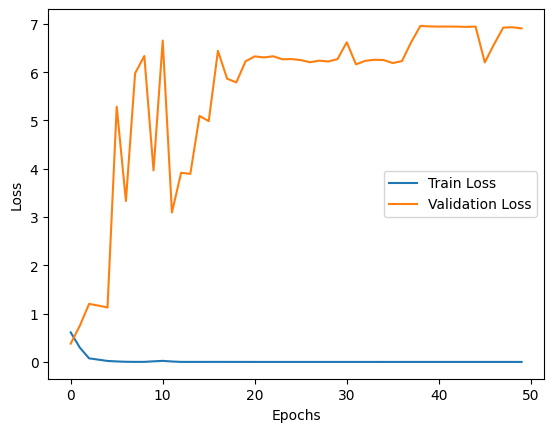

In [8]:
# plot the val loss and train loss
import matplotlib.pyplot as plt
plt.plot(model_train_loss, label='Train Loss')
plt.plot(model_val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [9]:
def evaluate_model(model):
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model(images).view(-1)
            predicted = outputs > 0.5 # Threshold predictions
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        accuracy = 100 * correct / total
        # print(f'Validation Set Accuracy: {accuracy:.2f}%')
    return accuracy

trained_models = {}
trained_models['baseline'] = {
    'model': model,
    'accuracy': evaluate_model(model),
    'loss': model_train_loss,
    'val_loss': model_val_loss
}
print(f"Baseline model accuracy stored: {trained_models['baseline']['accuracy']:.2f}%")

Baseline model accuracy stored: 85.94%


## Print a sample of the model's predictions wrong and correct

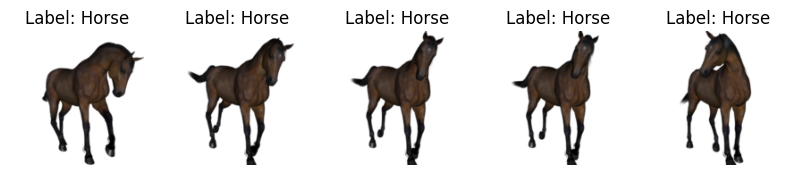

In [10]:
# create a function to print a sample of x amount of images and their labels for the validation set
import matplotlib.pyplot as plt
def print_sample_images(loader, num_images=5):
    data_iter = iter(loader)
    images, labels = next(data_iter)
    
    # Convert to CPU and numpy for plotting
    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    
    plt.figure(figsize=(10, 10))
    for i in range(num_images):
        plt.subplot(1, num_images, i + 1)
        plt.imshow(images[i].transpose(1, 2, 0) * 0.5 + 0.5)  # Unnormalize
        plt.title('Label: {}'.format('Horse' if labels[i] == 0 else 'Human'))
        plt.axis('off')
    plt.show()

print_sample_images(val_loader, num_images=5)

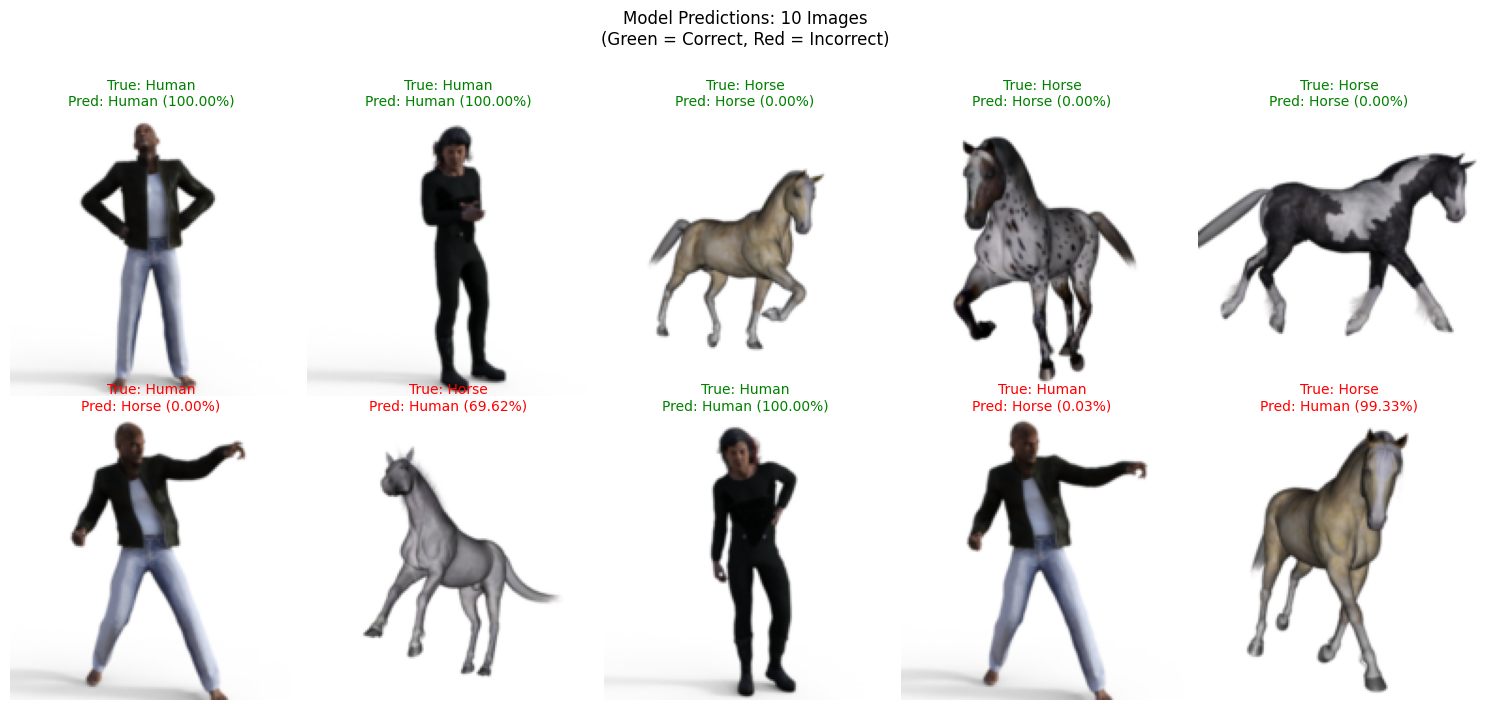


Prediction Summary:
Correct Horses: 94
Correct Humans: 126
Incorrect Horses (predicted as Human): 34
Incorrect Humans (predicted as Horse): 2
Overall Accuracy: 85.94%


In [11]:
# ...existing code...
import matplotlib.pyplot as plt
import numpy as np

def print_predictions(model, loader, num_images=10):
    """
    Display model predictions showing both correct and incorrect predictions
    evenly split between horses and humans.
    
    Args:
        model: Trained PyTorch model
        loader: DataLoader for validation/test set
        num_images: Total number of images to display (default 10)
    """
    model.eval()
    model.to(device)
    
    # Collect predictions
    correct_horses = []
    correct_humans = []
    incorrect_horses = []
    incorrect_humans = []
    
    with torch.no_grad():
        for images, labels in loader:
            images_device = images.to(device)
            labels_float = labels.float().to(device)
            
            outputs = model(images_device).squeeze()
            predicted = (outputs > 0.5).float()
            
            # Process each image in the batch
            for i in range(len(labels)):
                img = images[i].cpu().numpy()
                true_label = labels[i].item()
                pred_label = predicted[i].cpu().item()
                confidence = outputs[i].cpu().item()
                
                is_correct = (true_label == pred_label)
                
                # Store image info based on true label and correctness
                img_info = (img, true_label, pred_label, confidence)
                
                if true_label == 0:  # Horse
                    if is_correct:
                        correct_horses.append(img_info)
                    else:
                        incorrect_horses.append(img_info)
                else:  # Human
                    if is_correct:
                        correct_humans.append(img_info)
                    else:
                        incorrect_humans.append(img_info)
    
    # Select images to display
    images_per_category = num_images // 4
    remainder = num_images % 4
    
    selected_images = []
    
    # Add images from each category
    categories = [
        (correct_horses, "Correct - Horse"),
        (correct_humans, "Correct - Human"),
        (incorrect_horses, "Incorrect - Should be Horse"),
        (incorrect_humans, "Incorrect - Should be Human")
    ]
    
    for idx, (category_list, category_name) in enumerate(categories):
        # Calculate how many images to take from this category
        n_to_take = images_per_category
        if idx < remainder:
            n_to_take += 1
            
        # Randomly sample from available images
        if len(category_list) >= n_to_take:
            sampled = np.random.choice(len(category_list), n_to_take, replace=False)
            for i in sampled:
                selected_images.append((category_list[i], category_name))
        else:
            # If not enough images in category, take all available
            for img_info in category_list:
                selected_images.append((img_info, category_name))
    
    # Shuffle the selected images for mixed display
    np.random.shuffle(selected_images)
    
    # Display the images
    n_display = len(selected_images)
    if n_display == 0:
        print("No images to display!")
        return
    
    # Calculate grid dimensions
    cols = min(5, n_display)
    rows = (n_display + cols - 1) // cols
    
    plt.figure(figsize=(cols * 3, rows * 3.5))
    
    for idx, ((img, true_label, pred_label, confidence), category) in enumerate(selected_images):
        plt.subplot(rows, cols, idx + 1)
        
        # Unnormalize the image
        img_display = img.transpose(1, 2, 0) * 0.5 + 0.5
        img_display = np.clip(img_display, 0, 1)
        
        plt.imshow(img_display)
        
        # Create title with prediction info
        true_class = "Horse" if true_label == 0 else "Human"
        pred_class = "Horse" if pred_label == 0 else "Human"
        
        # Color code: green for correct, red for incorrect
        color = 'green' if true_label == pred_label else 'red'
        
        title = f'True: {true_class}\nPred: {pred_class} ({confidence:.2%})'
        plt.title(title, color=color, fontsize=10)
        plt.axis('off')
    
    plt.suptitle(f'Model Predictions: {n_display} Images\n(Green = Correct, Red = Incorrect)', 
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\nPrediction Summary:")
    print(f"Correct Horses: {len(correct_horses)}")
    print(f"Correct Humans: {len(correct_humans)}")
    print(f"Incorrect Horses (predicted as Human): {len(incorrect_horses)}")
    print(f"Incorrect Humans (predicted as Horse): {len(incorrect_humans)}")
    
    total_correct = len(correct_horses) + len(correct_humans)
    total_images = total_correct + len(incorrect_horses) + len(incorrect_humans)
    if total_images > 0:
        accuracy = (total_correct / total_images) * 100
        print(f"Overall Accuracy: {accuracy:.2f}%")

# Call the function to display predictions
print_predictions(model, val_loader, num_images=10)

## Continuing with examples - Image augmentation
Now apply image augmentation to the dataset and train the model again.
Apply:
* Rotation (turning the image)
* Shifting horizontally (moving the pixels horizontally with wrapping)
* Shifting vertically (moving the pixels vertically with wrapping)
* Shearing (slanting the image - moving the pixels either horizontally or vertically but offstetting so that the image would look like a parallelogram)
* Zooming (magnifying a particular region)
* Flipping (vertically or horizontally)

In [12]:
transform_augmented = transforms.Compose([
    transforms.Resize((150, 150)),
    transforms.RandomRotation(30),            # Random rotation
    transforms.RandomResizedCrop(150, scale=(0.8, 1.0)),  # Random crop and resize
    transforms.RandomHorizontalFlip(),        # Random horizontal flip
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Load the datasets with augmentation for training set
train_dataset_augmented = datasets.ImageFolder(root=training_dir,
                                               transform=transform_augmented)
val_dataset_augmented = datasets.ImageFolder(root=validation_dir,
                                             transform=transform)  # Validation set remains unchanged

# DataLoaders
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=32, shuffle=True)
val_loader_augmented = DataLoader(val_dataset_augmented, batch_size=32, shuffle=False)

model = HorsesHumansCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)  # recreate optimizer for new model
aug_train_loss, aug_val_loss = train_model(num_epochs=50,
                                           train_loader=train_loader_augmented,
                                           val_loader=val_loader_augmented)
trained_models['augmented'] = {
    'model': model,
    'accuracy': evaluate_model(model),
    'loss': aug_train_loss,
    'val_loss': aug_val_loss
}
print(f"Augmented model accuracy stored: {trained_models['augmented']['accuracy']:.2f}%")

Epoch 1, Loss: 0.6990
Validation Set Accuracy: 50.00%
Epoch 1, Train Loss: 0.6990 | Val Loss: 0.7817
Epoch 2, Loss: 0.5274
Validation Set Accuracy: 94.14%
Epoch 2, Train Loss: 0.5274 | Val Loss: 0.3588
Epoch 3, Loss: 0.3492
Validation Set Accuracy: 89.45%
Epoch 3, Train Loss: 0.3492 | Val Loss: 0.2785
Epoch 4, Loss: 0.2000
Validation Set Accuracy: 72.27%
Epoch 4, Train Loss: 0.2000 | Val Loss: 1.1967
Epoch 5, Loss: 0.1648
Validation Set Accuracy: 83.20%
Epoch 5, Train Loss: 0.1648 | Val Loss: 0.6758
Epoch 6, Loss: 0.1122
Validation Set Accuracy: 77.34%
Epoch 6, Train Loss: 0.1122 | Val Loss: 2.3877
Epoch 7, Loss: 0.1064
Validation Set Accuracy: 78.12%
Epoch 7, Train Loss: 0.1064 | Val Loss: 1.4395
Epoch 8, Loss: 0.0924
Validation Set Accuracy: 79.69%
Epoch 8, Train Loss: 0.0924 | Val Loss: 2.1080
Epoch 9, Loss: 0.0780
Validation Set Accuracy: 70.31%
Epoch 9, Train Loss: 0.0780 | Val Loss: 4.6372
Epoch 10, Loss: 0.0700
Validation Set Accuracy: 76.17%
Epoch 10, Train Loss: 0.0700 | Val L

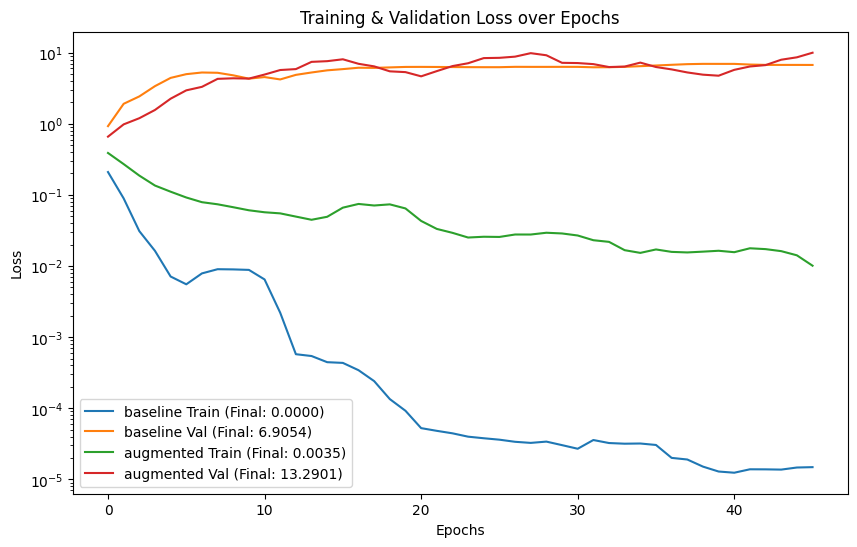

In [13]:
# create a function to plot the loss of multiple models
def plot_multiple_losses(trained_models):
    plt.figure(figsize=(10, 6))
    for name, info in trained_models.items():
        train_loss = info['loss']
        val_loss = info.get('val_loss')
        # Optionally smooth the loss
        smooth = lambda x, w=5: np.convolve(x, np.ones(w)/w, mode='valid')
        plt.plot(smooth(train_loss), label=f'{name} Train (Final: {train_loss[-1]:.4f})')
        if val_loss is not None:
            plt.plot(smooth(val_loss), label=f'{name} Val (Final: {val_loss[-1]:.4f})')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss over Epochs')
    plt.legend()
    plt.yscale('log')  # Use log scale if loss drops quickly
    plt.show()
plot_multiple_losses(trained_models)

## Transfer learning

In [22]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torch.optim import RMSprop

# Load pretrained Inception V3 model
pre_trained_model = models.inception_v3(pretrained=True, aux_logits=True)

def print_model_summary(model):
    for name, module in model.named_modules():
        print(f"{name} : {module.__class__.__name__}")

print_model_summary(pre_trained_model)

 : Inception3
Conv2d_1a_3x3 : BasicConv2d
Conv2d_1a_3x3.conv : Conv2d
Conv2d_1a_3x3.bn : BatchNorm2d
Conv2d_2a_3x3 : BasicConv2d
Conv2d_2a_3x3.conv : Conv2d
Conv2d_2a_3x3.bn : BatchNorm2d
Conv2d_2b_3x3 : BasicConv2d
Conv2d_2b_3x3.conv : Conv2d
Conv2d_2b_3x3.bn : BatchNorm2d
maxpool1 : MaxPool2d
Conv2d_3b_1x1 : BasicConv2d
Conv2d_3b_1x1.conv : Conv2d
Conv2d_3b_1x1.bn : BatchNorm2d
Conv2d_4a_3x3 : BasicConv2d
Conv2d_4a_3x3.conv : Conv2d
Conv2d_4a_3x3.bn : BatchNorm2d
maxpool2 : MaxPool2d
Mixed_5b : InceptionA
Mixed_5b.branch1x1 : BasicConv2d
Mixed_5b.branch1x1.conv : Conv2d
Mixed_5b.branch1x1.bn : BatchNorm2d
Mixed_5b.branch5x5_1 : BasicConv2d
Mixed_5b.branch5x5_1.conv : Conv2d
Mixed_5b.branch5x5_1.bn : BatchNorm2d
Mixed_5b.branch5x5_2 : BasicConv2d
Mixed_5b.branch5x5_2.conv : Conv2d
Mixed_5b.branch5x5_2.bn : BatchNorm2d
Mixed_5b.branch3x3dbl_1 : BasicConv2d
Mixed_5b.branch3x3dbl_1.conv : Conv2d
Mixed_5b.branch3x3dbl_1.bn : BatchNorm2d
Mixed_5b.branch3x3dbl_2 : BasicConv2d
Mixed_5b.branc

In [23]:
# print a better summary of the model
from torchsummary import summary
summary(pre_trained_model, input_size=(3, 299, 299), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 149, 149]             864
       BatchNorm2d-2         [-1, 32, 149, 149]              64
       BasicConv2d-3         [-1, 32, 149, 149]               0
            Conv2d-4         [-1, 32, 147, 147]           9,216
       BatchNorm2d-5         [-1, 32, 147, 147]              64
       BasicConv2d-6         [-1, 32, 147, 147]               0
            Conv2d-7         [-1, 64, 147, 147]          18,432
       BatchNorm2d-8         [-1, 64, 147, 147]             128
       BasicConv2d-9         [-1, 64, 147, 147]               0
        MaxPool2d-10           [-1, 64, 73, 73]               0
           Conv2d-11           [-1, 80, 73, 73]           5,120
      BatchNorm2d-12           [-1, 80, 73, 73]             160
      BasicConv2d-13           [-1, 80, 73, 73]               0
           Conv2d-14          [-1, 192,

In [24]:
# Freeze all layers up to and including the 'Mixed_7c'
for name, parameter in pre_trained_model.named_parameters():
    parameter.requires_grad = False
    if 'Mixed_7c' in name:
        break

# Modify the existing fully connected layer
num_ftrs = pre_trained_model.fc.in_features
pre_trained_model.fc = nn.Sequential(
    nn.Linear(num_ftrs, 1024),  # New fully connected layer with 1024 outputs
    nn.ReLU(),                # Activation layer
    nn.Linear(1024, 2)         # Final layer for binary classification
)

transform = transforms.Compose([
    transforms.Resize((299, 299)),  # Resize to match Inception V3 input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Load datasets using ImageFolder
train_dataset = ImageFolder(root=training_dir, transform=transform)
val_dataset = ImageFolder(root=validation_dir, transform=transform)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

def train_model(model, criterion, optimizer, train_loader, num_epochs=10):
    model.train()  # Set the model to training mode
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    for epoch in range(num_epochs):
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            # Handle multiple outputs for training with auxiliary logits
            if isinstance(outputs, tuple):
                output, aux_output = outputs
                loss1 = criterion(output, labels)
                loss2 = criterion(aux_output, labels)
                loss = loss1 + 0.4 * loss2  # Scale the auxiliary loss as is standard for Inception
            else:
                loss = criterion(outputs, labels)

            _, preds = torch.max(output, 1)  # Ensure you use the main output for accuracy calculation

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            # Update statistics
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects / len(train_loader.dataset)

        print(f'Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.4f}')



# Only optimize parameters that are set to be trainable
optimizer = RMSprop(filter(lambda p: p.requires_grad, pre_trained_model.parameters()), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train the model
train_model(pre_trained_model, criterion, optimizer, train_loader, num_epochs=3)

Epoch 1/3 - Loss: 4.8249, Acc: 0.9523
Epoch 2/3 - Loss: 3.4426, Acc: 0.9990
Epoch 3/3 - Loss: 3.4380, Acc: 0.9990


In [25]:
# evaluate the model
def evaluate_model(model, val_loader):
    model.eval()  # Set the model to evaluation mode
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    running_corrects = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            if isinstance(outputs, tuple):
                output, _ = outputs  # Use only the main output for evaluation
            else:
                output = outputs

            _, preds = torch.max(output, 1)
            running_corrects += torch.sum(preds == labels).item()
            total_samples += labels.size(0)

    accuracy = running_corrects / total_samples
    print(f'Validation Accuracy: {accuracy:.4f}')
    return accuracy

# Evaluate the model
val_accuracy = evaluate_model(pre_trained_model, val_loader)
trained_models['pre_trained_inception'] = {
    'model': pre_trained_model,
    'accuracy': val_accuracy,
    'loss': None,  # Loss not tracked in this case
    'val_loss': None  # Loss not tracked in this case
}
print(f"Pre-trained Inception model accuracy stored: {trained_models['pre_trained_inception']['accuracy']:.2f}%")

Validation Accuracy: 0.9844
Pre-trained Inception model accuracy stored: 0.98%


In [27]:
def evaluate_model(model, data_loader, device):
    model.eval()  # Set the model to evaluation mode
    total = 0
    corrects = 0

    with torch.no_grad():  # No need to track gradients for evaluation
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            # Handle multiple outputs during evaluation
            if isinstance(outputs, tuple):
                outputs = outputs[0]  # Use only the main output for evaluation

            _, preds = torch.max(outputs, 1)
            corrects += torch.sum(preds == labels).item()
            total += labels.size(0)

    accuracy = corrects / total
    print(f'Accuracy on the validation set: {accuracy:.4f} ({corrects}/{total})')
    return accuracy

# Assuming the necessary imports and pre_trained_model are defined and set up
# Ensure the model and data loaders are on the appropriate device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
pre_trained_model = pre_trained_model.to(device)

# Assuming val_loader is defined and set up as previously shown

accuracy = evaluate_model(pre_trained_model, val_loader, device)

Accuracy on the validation set: 0.9844 (252/256)


# Dropout regularization

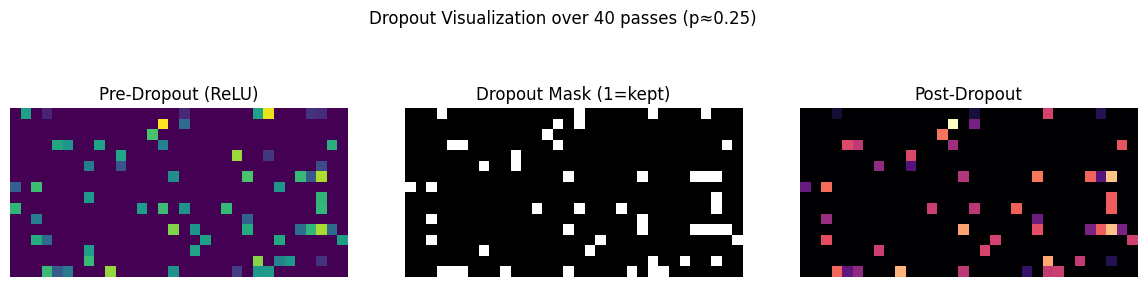

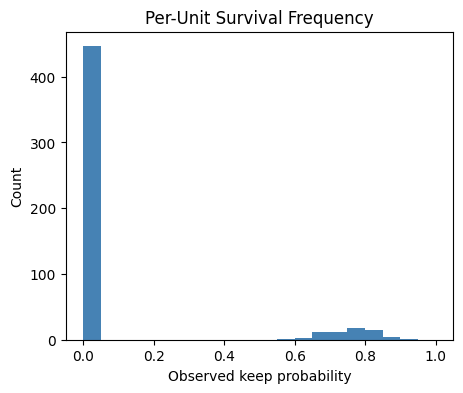

In [33]:
# Dropout visualization utilities
import torch, math
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display
import numpy as np

def _get_named_module(model, name: str):
    """Return submodule by attribute name (one level) or dotted path; None if missing."""
    current = model
    for part in name.split('.'):
        if not hasattr(current, part):
            return None
        current = getattr(current, part)
    return current


def visualize_dropout(model: torch.nn.Module,
                       data_loader,
                       device=None,
                       dropout_attr: str = 'drop',
                       fc_attr: str = 'fc1',
                       sample_index: int = 0,
                       passes: int = 30,
                       interval: int = 300,
                       figsize=(12,4),
                       return_data: bool = False):
    """Animate dropout stochastic behavior for a fully-connected layer followed by a Dropout.

    Parameters
    ----------
    model : nn.Module
        Model containing a linear layer (fc_attr) -> activation -> dropout (dropout_attr).
    data_loader : DataLoader
        Loader to draw a single batch/sample from.
    device : torch.device or None
        Device to run on (defaults to model's first parameter device or CPU).
    dropout_attr : str
        Attribute name of the dropout module inside model.
    fc_attr : str
        Attribute name of the preceding fully connected layer (before ReLU + dropout).
    sample_index : int
        Index within the batch to visualize.
    passes : int
        Number of stochastic forward passes (frames).
    interval : int
        Milliseconds between frames.
    figsize : tuple
        Figure size.
    return_data : bool
        If True, also return (pre_acts, post_acts, mask_array, survival_rate).
    """
    model.train()  # ensure dropout active
    model = model
    if device is None:
        device = next(model.parameters()).device if any(True for _ in model.parameters()) else torch.device('cpu')

    # Fetch one batch
    batch = next(iter(data_loader))
    if isinstance(batch, (list, tuple)):
        inputs = batch[0][sample_index:sample_index+1]
    else:
        raise ValueError("DataLoader must return (inputs, labels) tuple.")
    inputs = inputs.to(device)

    # Locate modules
    fc_layer = _get_named_module(model, fc_attr)
    dropout_layer = _get_named_module(model, dropout_attr)
    if fc_layer is None or dropout_layer is None:
        raise AttributeError(f"Could not find layers '{fc_attr}' and/or '{dropout_attr}' in model.")

    pre_linear_outputs = []  # raw linear outputs
    post_dropout_outputs = []

    def hook_fc(_, __, out):
        pre_linear_outputs.append(out.detach().clone())

    def hook_drop(_, __, out):
        post_dropout_outputs.append(out.detach().clone())

    h1 = fc_layer.register_forward_hook(hook_fc)
    h2 = dropout_layer.register_forward_hook(hook_drop)

    with torch.no_grad():
        for _ in range(passes):
            _ = model(inputs)

    # Remove hooks
    h1.remove(); h2.remove()

    # Convert to tensors: apply ReLU to fc outputs (model does this before dropout)
    pre_relu = torch.relu(torch.stack(pre_linear_outputs, dim=0).squeeze(1))  # (passes, features)
    post = torch.stack(post_dropout_outputs, dim=0).squeeze(1)  # already after dropout

    # Determine scaling (inverted dropout) to isolate mask: active units => approx pre_relu * 1/(1-p)
    # We compute mask as (post != 0) & (pre_relu != 0) to exclude zeros from ReLU.
    mask = (post != 0) & (pre_relu != 0)
    survival_rate = mask.float().mean(dim=0)  # per-unit survival frequency

    # Reshape feature vector to grid for visualization (heuristic: near-square)
    feat_dim = pre_relu.shape[1]
    side = int(math.sqrt(feat_dim))
    if side * side == feat_dim:
        grid_shape = (side, side)
    else:
        # Find factor pair closest to square
        factors = [(i, feat_dim // i) for i in range(1, int(math.sqrt(feat_dim))+1) if feat_dim % i == 0]
        grid_shape = min(factors, key=lambda ab: abs(ab[0]-ab[1]))
    def to_grid(vec):
        return vec.view(*grid_shape).cpu().numpy()

    pre_frames = [to_grid(pre_relu[i]) for i in range(passes)]
    post_frames = [to_grid(post[i]) for i in range(passes)]
    mask_frames = [to_grid(mask[i].float()) for i in range(passes)]

    vmax_pre = np.max([f.max() for f in pre_frames]) or 1.0
    vmax_post = np.max([f.max() for f in post_frames]) or 1.0

    fig, axs = plt.subplots(1, 3, figsize=figsize)
    plt.tight_layout()
    im0 = axs[0].imshow(pre_frames[0], cmap='viridis', vmin=0, vmax=vmax_pre)
    axs[0].set_title('Pre-Dropout (ReLU)')
    im1 = axs[1].imshow(mask_frames[0], cmap='gray', vmin=0, vmax=1)
    axs[1].set_title('Dropout Mask (1=kept)')
    im2 = axs[2].imshow(post_frames[0], cmap='magma', vmin=0, vmax=vmax_post)
    axs[2].set_title('Post-Dropout')
    for ax in axs: ax.axis('off')
    fig.suptitle(f'Dropout Visualization over {passes} passes (p≈{getattr(dropout_layer, "p", "?")})')

    def update(frame):
        im0.set_data(pre_frames[frame])
        im1.set_data(mask_frames[frame])
        im2.set_data(post_frames[frame])
        return im0, im1, im2

    anim = animation.FuncAnimation(fig, update, frames=passes, interval=interval, blit=True, repeat=True)
    display(HTML(anim.to_jshtml()))

    # Static survival rate visualization
    plt.figure(figsize=(5,4))
    plt.hist(survival_rate.cpu().numpy(), bins=20, range=(0,1), color='steelblue')
    plt.title('Per-Unit Survival Frequency')
    plt.xlabel('Observed keep probability'); plt.ylabel('Count')
    plt.show()

    if return_data:
        return {
            'pre_relu': pre_relu,
            'post': post,
            'mask': mask,
            'survival_rate': survival_rate,
            'animation': anim
        }

# Example usage (uncomment to run after model & loaders are defined):
# Use the augmented train loader which has 150x150 images that match the model architecture
visualize_dropout(trained_models['baseline']['model'], train_loader_augmented, device="mps", passes=40, interval=250)


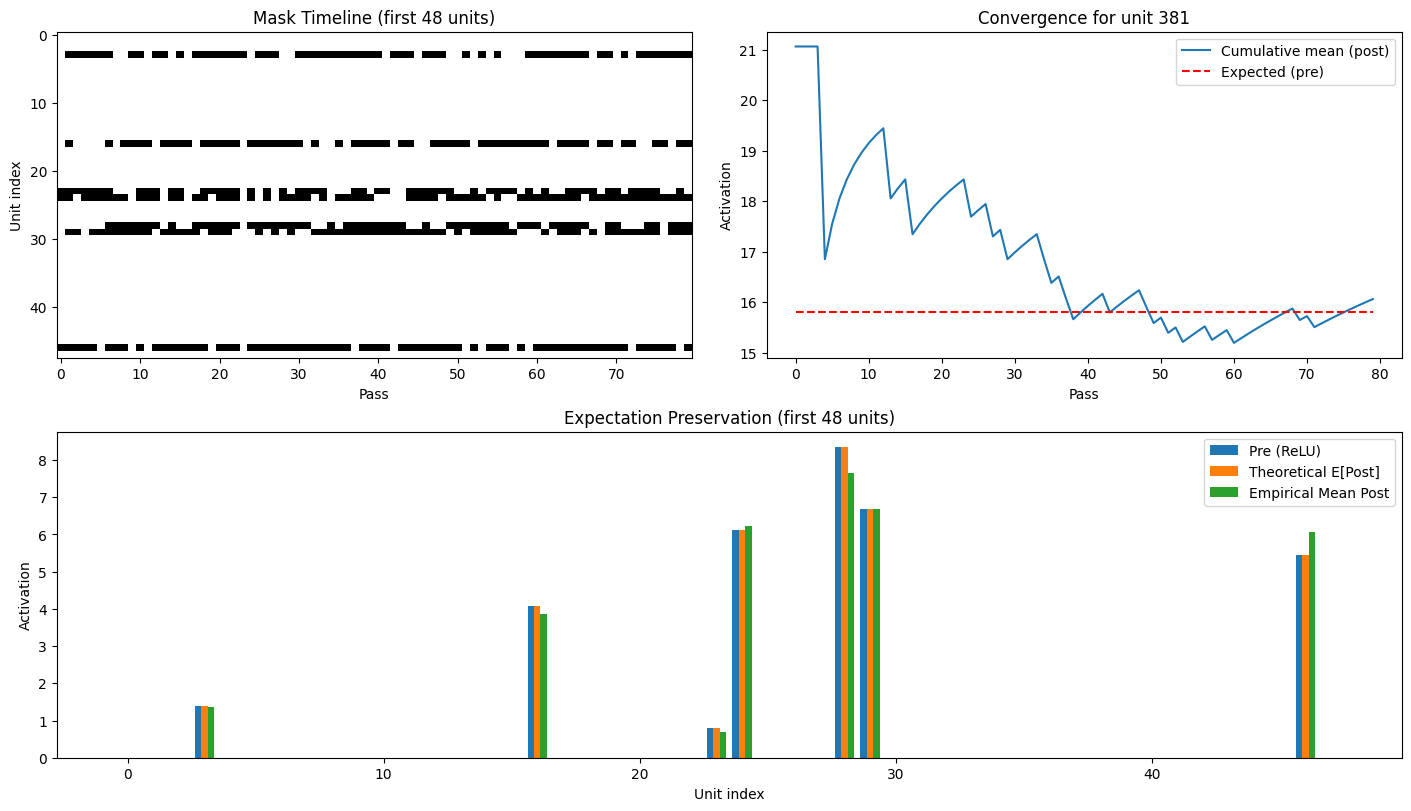

Observed global keep ratio ≈ 0.086 (target ≈ 0.75)
Relative L2 error between empirical and theoretical expectation (subset) = 6.8837e-02


In [36]:
# Alternative visualization: expectation convergence & mask timeline
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import numpy as np
import torch, math


def visualize_dropout_expectation(model: torch.nn.Module,
                                   data_loader,
                                   device=None,
                                   fc_attr='fc1',
                                   dropout_attr='drop',
                                   sample_index: int = 0,
                                   passes: int = 60,
                                   units_to_show: int = 32,
                                   seed: int = 42):
    """Visualize dropout as stochastic masking and expectation preservation.

    Shows:
      1. Mask timeline heatmap (kept=1, dropped=0) for a subset of hidden units across stochastic passes.
      2. Convergence of cumulative mean of post-dropout activations toward the original (pre-dropout) activation.
      3. Bar chart comparing per-unit: pre-activation (after ReLU), empirical mean post-dropout, and theoretical expectation.

    In inverted dropout (PyTorch), y = (a * m)/(1-p), with m~Bernoulli(1-p). E[y] = a.

    Parameters
    ----------
    model : nn.Module
    data_loader : DataLoader supplying (inputs, labels)
    device : torch.device or None
    fc_attr : str name of linear layer before dropout
    dropout_attr : str name of dropout layer
    sample_index : which sample in the batch
    passes : number of stochastic forward passes
    units_to_show : subset of first N units to plot in heatmap/bar chart
    seed : RNG seed for reproducibility
    """
    rng_state = torch.random.get_rng_state()
    torch.manual_seed(seed)

    if device is None:
        device = next(model.parameters()).device if any(True for _ in model.parameters()) else torch.device('cpu')

    model.train()  # ensure dropout active

    # Grab one batch
    batch = next(iter(data_loader))
    if not isinstance(batch, (tuple, list)):
        raise ValueError("DataLoader must return (inputs, labels).")
    x = batch[0][sample_index:sample_index+1].to(device)

    # Resolve layers
    def _get(model, name):
        cur = model
        for part in name.split('.'):
            if not hasattr(cur, part):
                raise AttributeError(f"Layer '{name}' not found (stuck at '{part}').")
            cur = getattr(cur, part)
        return cur

    fc_layer = _get(model, fc_attr)
    drop_layer = _get(model, dropout_attr)
    p = getattr(drop_layer, 'p', None)

    pre_outputs = []
    post_outputs = []

    def hook_fc(_, __, out):
        pre_outputs.append(out.detach().clone())

    def hook_drop(_, __, out):
        post_outputs.append(out.detach().clone())

    h1 = fc_layer.register_forward_hook(hook_fc)
    h2 = drop_layer.register_forward_hook(hook_drop)

    with torch.no_grad():
        for _ in range(passes):
            _ = model(x)

    h1.remove(); h2.remove()

    pre = torch.relu(torch.stack(pre_outputs).squeeze(1))  # (passes, features)
    post = torch.stack(post_outputs).squeeze(1)            # (passes, features)

    # Derive mask: post = pre * mask / (1-p)  (for non-zero pre). Handle zeros robustly.
    if p is not None and p < 1.0:
        scale = (1 - p)
        # Where pre>0, mask ≈ (post * (1-p)) / pre rounded to {0,1}
        eps = 1e-8
        mask_est = torch.zeros_like(post)
        positive = pre > eps
        mask_est[positive] = ((post[positive] * scale) / (pre[positive] + eps)).clamp(0,1)
        mask = (mask_est > 0.5).float()
    else:
        mask = (post != 0).float()

    # Choose subset of units
    feat_dim = pre.shape[1]
    units = min(units_to_show, feat_dim)
    pre0 = pre[0]  # first pass pre-activation (deterministic part varies little for fixed input)

    # Expectation for inverted dropout: E[post] = pre0 (per pass the same expectation)
    empirical_mean = post.mean(0)
    cumulative_mean = torch.cumsum(post, dim=0) / torch.arange(1, passes+1, device=post.device).unsqueeze(1)

    # Prepare plots
    fig = plt.figure(constrained_layout=True, figsize=(14, 8))
    gs = fig.add_gridspec(2, 2)

    # 1. Mask timeline
    ax_mask = fig.add_subplot(gs[0, 0])
    ax_mask.imshow(mask[:, :units].cpu().numpy().T, aspect='auto', cmap='Greys')
    ax_mask.set_title(f'Mask Timeline (first {units} units)')
    ax_mask.set_xlabel('Pass')
    ax_mask.set_ylabel('Unit index')

    # 2. Single-unit convergence (choose the unit with highest variance)
    variances = post.var(0)
    focus_unit = int(torch.argmax(variances).item()) if feat_dim > 0 else 0
    ax_conv = fig.add_subplot(gs[0, 1])
    ax_conv.plot(cumulative_mean[:, focus_unit].cpu().numpy(), label='Cumulative mean (post)')
    ax_conv.hlines(pre0[focus_unit].cpu().item(), 0, passes-1, colors='r', linestyles='--', label='Expected (pre)')
    ax_conv.set_title(f'Convergence for unit {focus_unit}')
    ax_conv.set_xlabel('Pass')
    ax_conv.set_ylabel('Activation')
    ax_conv.legend()

    # 3 & 4. Bar chart: first N units (split across two axes if large)
    # Gather data
    pre_vals = pre0[:units].cpu().numpy()
    emp_vals = empirical_mean[:units].cpu().numpy()
    exp_vals = pre_vals  # expectation matches pre

    width = 0.25
    x_idx = np.arange(units)

    ax_bar = fig.add_subplot(gs[1, :])
    ax_bar.bar(x_idx - width, pre_vals, width, label='Pre (ReLU)')
    ax_bar.bar(x_idx, exp_vals, width, label='Theoretical E[Post]')
    ax_bar.bar(x_idx + width, emp_vals, width, label='Empirical Mean Post')
    ax_bar.set_title(f'Expectation Preservation (first {units} units)')
    ax_bar.set_xlabel('Unit index')
    ax_bar.set_ylabel('Activation')
    ax_bar.legend()
    plt.show()

    # Summary text
    kept_ratio = mask.mean().item()
    print(f"Observed global keep ratio ≈ {kept_ratio:.3f} (target ≈ {1-p if p is not None else 'unknown'})")
    l2_rel_error = np.linalg.norm(emp_vals - exp_vals) / (np.linalg.norm(exp_vals)+1e-8)
    print(f"Relative L2 error between empirical and theoretical expectation (subset) = {l2_rel_error:.4e}")

    # Restore RNG state
    torch.random.set_rng_state(rng_state)

    return {
        'pre': pre,
        'post': post,
        'mask': mask,
        'empirical_mean': empirical_mean,
        'cumulative_mean': cumulative_mean,
        'focus_unit': focus_unit
    }

# Example usage (uncomment to run):
exp_data = visualize_dropout_expectation(trained_models['baseline']['model'], train_loader_augmented, device='mps', passes=80, units_to_show=48)


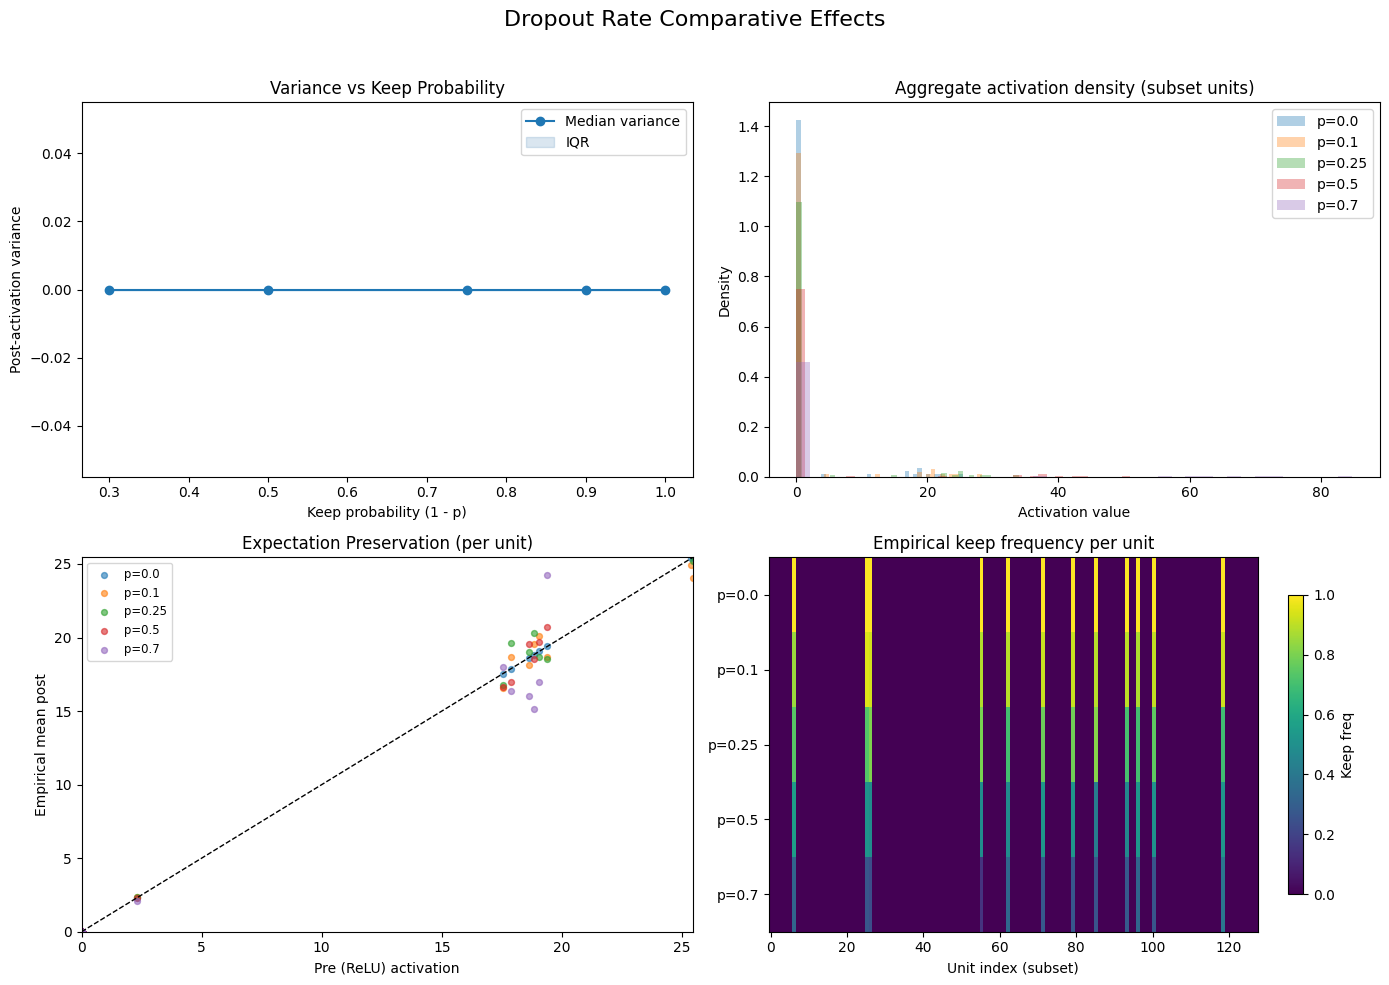

Summary:
  p=0.00 -> empirical keep 0.098, median var 0.0000
  p=0.10 -> empirical keep 0.088, median var 0.0000
  p=0.25 -> empirical keep 0.073, median var 0.0000
  p=0.50 -> empirical keep 0.049, median var 0.0000
  p=0.70 -> empirical keep 0.029, median var 0.0000


In [43]:
# Comparative visualization: effect of different dropout rates on activation statistics
import torch
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle


def visualize_dropout_rate_effect(model: torch.nn.Module,
                                   data_loader,
                                   device=None,
                                   dropout_attr: str = 'drop',
                                   fc_attr: str = 'fc1',
                                   sample_index: int = 0,
                                   rates = (0.0, 0.1, 0.25, 0.5, 0.7),
                                   passes: int = 120,
                                   max_units: int = 128,
                                   seed: int = 123):
    """Compare how different dropout probabilities change activation distributions & variance.

    For each rate p in `rates` (drop probability):
      - Temporarily set dropout.p = p
      - Run `passes` stochastic forward passes on a fixed sample
      - Record post-dropout activations (after dropout, before final layer)
      - Compute per-unit mean, variance, empirical keep ratio

    Plots:
      1. Variance vs Keep Probability (1-p) aggregated (median & IQR)
      2. Distribution (kernel-ish histogram) of a consistent subset of units across rates
      3. Mean vs Empirical Expectation Scatter (should lie near y=x)
      4. Activation sparsity heatmap (first N units × rates) showing fraction of times unit kept

    Returns dict of collected statistics.
    """
    torch.manual_seed(seed)
    if device is None:
        device = next(model.parameters()).device if any(True for _ in model.parameters()) else torch.device('cpu')

    # Resolve modules
    def _get(mod, name):
        cur = mod
        for part in name.split('.'):
            if not hasattr(cur, part):
                raise AttributeError(f"Layer '{name}' not found (stuck at '{part}').")
            cur = getattr(cur, part)
        return cur
    drop_layer = _get(model, dropout_attr)
    fc_layer = _get(model, fc_attr)

    # Grab a single input sample
    batch = next(iter(data_loader))
    if not isinstance(batch, (tuple, list)):
        raise ValueError('Expected (inputs, labels) from data_loader')
    x = batch[0][sample_index:sample_index+1].to(device)

    original_p = drop_layer.p
    stats = {}

    pre_hook_outputs = []
    post_hook_outputs = []

    def hook_fc(_, __, out):
        pre_hook_outputs.append(out.detach().clone())
    def hook_drop(_, __, out):
        post_hook_outputs.append(out.detach().clone())

    # Register hooks once; we will clear lists each rate
    h1 = fc_layer.register_forward_hook(hook_fc)
    h2 = drop_layer.register_forward_hook(hook_drop)

    model.train()  # enable dropout

    for p in rates:
        # Update dropout probability
        drop_layer.p = p
        pre_hook_outputs.clear(); post_hook_outputs.clear()
        with torch.no_grad():
            for _ in range(passes):
                _ = model(x)
        pre = torch.relu(torch.stack(pre_hook_outputs).squeeze(1))  # after relu pre-dropout
        post = torch.stack(post_hook_outputs).squeeze(1)
        # Derive mask (handle inverted dropout scaling): post = pre * m / (1-p)
        if p < 1.0:
            scale = (1 - p)
            eps = 1e-8
            positive = pre > eps
            mask_est = torch.zeros_like(post)
            mask_est[positive] = ((post[positive] * scale) / (pre[positive] + eps)).clamp(0,1)
            mask = (mask_est > 0.5).float()
        else:
            mask = torch.zeros_like(post)
        keep_ratio_emp = mask.mean().item()
        mean_post = post.mean(0)
        var_post = post.var(0, unbiased=False)
        mean_pre = pre[0]  # deterministic part
        stats[p] = {
            'pre': pre,
            'post': post,
            'mask': mask,
            'keep_empirical': keep_ratio_emp,
            'mean_post': mean_post,
            'var_post': var_post,
            'mean_pre': mean_pre
        }

    # Restore original p
    drop_layer.p = original_p
    h1.remove(); h2.remove()

    # Determine unit count
    feat_dim = next(iter(stats.values()))['mean_post'].numel()
    units = min(max_units, feat_dim)
    unit_indices = torch.linspace(0, feat_dim-1, steps=units).long()

    # 1. Variance vs Keep Probability
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    ax_var = axs[0,0]
    keep_probs = []
    med_vars = []
    p25_vars = []
    p75_vars = []
    for p, d in stats.items():
        kp = 1 - p
        v = d['var_post'].cpu().numpy()
        keep_probs.append(kp)
        med_vars.append(np.median(v))
        p25_vars.append(np.percentile(v, 25))
        p75_vars.append(np.percentile(v, 75))
    order = np.argsort(keep_probs)
    kp_arr = np.array(keep_probs)[order]
    ax_var.plot(kp_arr, np.array(med_vars)[order], marker='o', label='Median variance')
    ax_var.fill_between(kp_arr, np.array(p25_vars)[order], np.array(p75_vars)[order], color='steelblue', alpha=0.2, label='IQR')
    ax_var.set_xlabel('Keep probability (1 - p)')
    ax_var.set_ylabel('Post-activation variance')
    ax_var.set_title('Variance vs Keep Probability')
    ax_var.legend()

    # 2. Distribution snapshot for subset units
    ax_dist = axs[0,1]
    colors = cycle(['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'])
    for p, color in zip(rates, colors):
        post = stats[p]['post'][:, unit_indices].cpu().numpy()  # (passes, units)
        flat = post.flatten()
        ax_dist.hist(flat, bins=40, alpha=0.35, density=True, color=color, label=f'p={p}')
    ax_dist.set_title('Aggregate activation density (subset units)')
    ax_dist.set_xlabel('Activation value')
    ax_dist.set_ylabel('Density')
    ax_dist.legend()

    # 3. Mean vs Expected scatter (should align y=x)
    ax_scatter = axs[1,0]
    for p, color in zip(rates, cycle(['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'])):
        mean_pre = stats[p]['mean_pre']
        mean_post = stats[p]['mean_post']
        ax_scatter.scatter(mean_pre[:units].cpu(), mean_post[:units].cpu(), s=18, alpha=0.6, label=f'p={p}')
    lims = [0, max(1e-6, float(max(v['mean_pre'][:units].max().item() for v in stats.values())))]
    ax_scatter.plot(lims, lims, 'k--', linewidth=1)
    ax_scatter.set_xlim(lims); ax_scatter.set_ylim(lims)
    ax_scatter.set_xlabel('Pre (ReLU) activation')
    ax_scatter.set_ylabel('Empirical mean post')
    ax_scatter.set_title('Expectation Preservation (per unit)')
    ax_scatter.legend(fontsize='small')

    # 4. Sparsity heatmap: empirical keep ratio per unit & rate
    ax_heat = axs[1,1]
    keep_matrix = []  # rows: rates, cols: unit indices
    for p in rates:
        mask = stats[p]['mask'][:, unit_indices]
        keep_matrix.append(mask.mean(0).cpu().numpy())
    keep_matrix = np.array(keep_matrix)
    im = ax_heat.imshow(keep_matrix, aspect='auto', cmap='viridis', vmin=0, vmax=1)
    ax_heat.set_yticks(range(len(rates)))
    ax_heat.set_yticklabels([f'p={p}' for p in rates])
    ax_heat.set_xlabel('Unit index (subset)')
    ax_heat.set_title('Empirical keep frequency per unit')
    fig.colorbar(im, ax=ax_heat, shrink=0.8, label='Keep freq')

    fig.suptitle('Dropout Rate Comparative Effects', fontsize=16)
    plt.tight_layout(rect=(0,0,1,0.96))
    plt.show()

    # Textual summary
    print('Summary:')
    for p in rates:
        print(f"  p={p:.2f} -> empirical keep {stats[p]['keep_empirical']:.3f}, median var {stats[p]['var_post'].median().item():.4f}")

    return stats

# Example usage (uncomment to run after baseline & augmented loaders exist):
rate_stats = visualize_dropout_rate_effect(trained_models['baseline']['model'], train_loader_augmented, device='mps', passes=120)

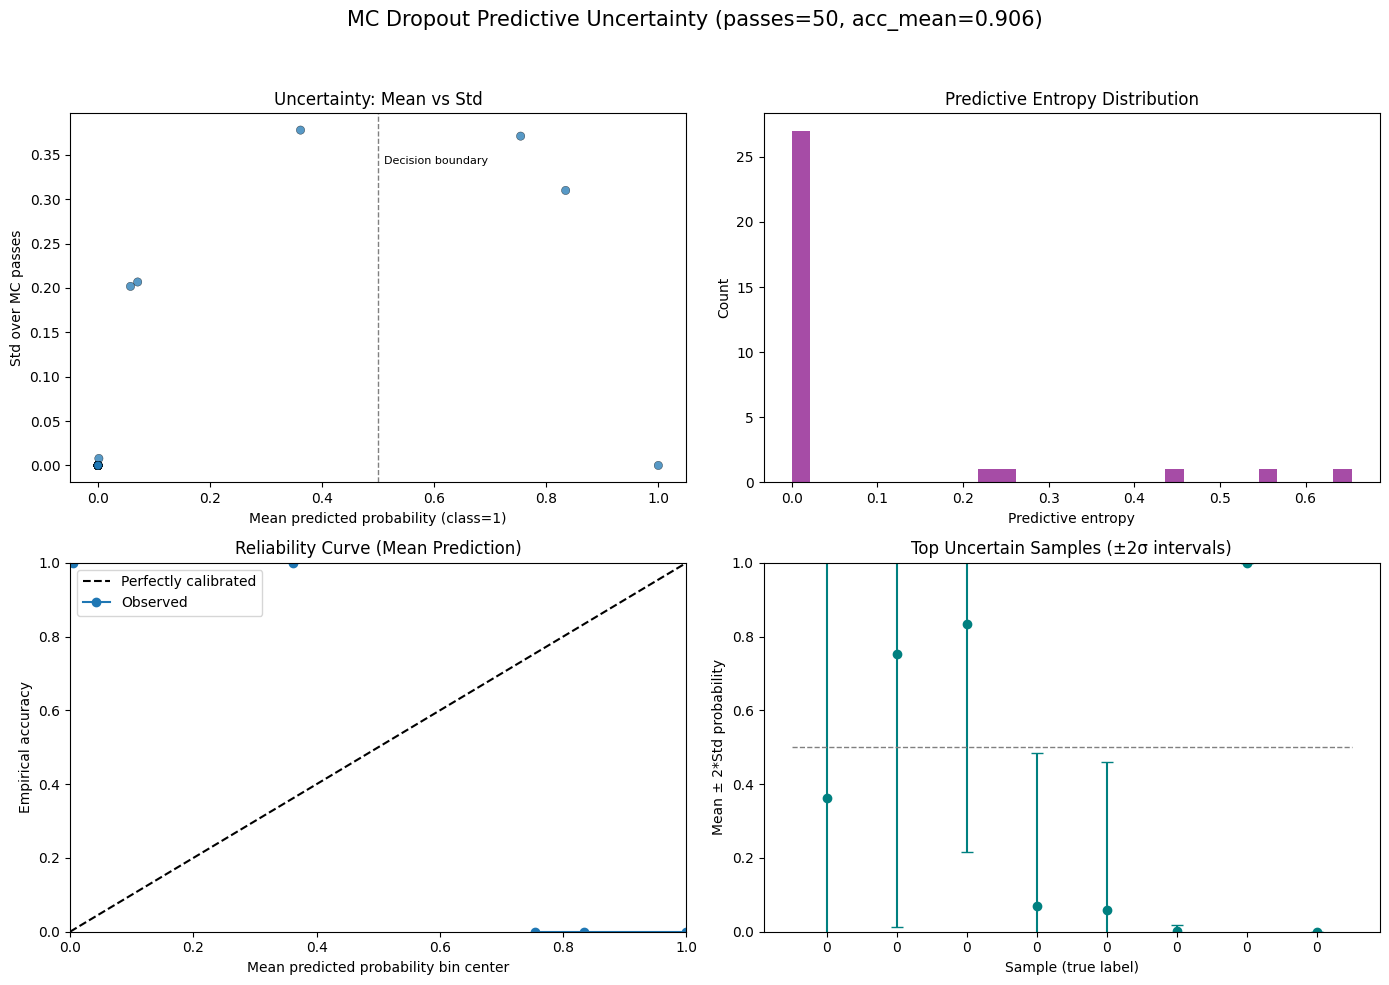

Mean prediction accuracy: 0.906
Average predictive entropy: 0.0671
Average mutual information (epistemic): 0.0446


In [44]:
# Monte Carlo Dropout: predictive uncertainty & calibration visualization
import torch, numpy as np, math
import matplotlib.pyplot as plt
from typing import Optional


def visualize_mc_dropout_uncertainty(model: torch.nn.Module,
                                      data_loader,
                                      device=None,
                                      passes: int = 50,
                                      max_samples: int = 64,
                                      dropout_attr: Optional[str] = None,
                                      seed: int = 123,
                                      show_images: int = 8):
    """Run multiple stochastic forward passes with dropout active to estimate uncertainty.

    For binary classification model returning probabilities (sigmoid output) or logits (if attribute `returns_logits` set):
      - Executes `passes` forward passes on first `max_samples` examples.
      - Collects per-sample predictive distribution.
      - Computes: mean probability, standard deviation, predictive entropy, mutual information (BALD approx).
      - Plots:
          1. Mean vs Std scatter (colored by true label; highlights uncertain zone).
          2. Predictive entropy histogram.
          3. Reliability (calibration) curve using mean probs vs empirical accuracy in bins.
          4. Error bar chart (mean ± 2*std) for a subset of samples (optionally with example images if available).
    Returns a dict with tensors & metrics.
    """
    torch.manual_seed(seed)
    if device is None:
        device = next(model.parameters()).device if any(True for _ in model.parameters()) else torch.device('cpu')

    # Put model in train mode to activate dropout
    model.train()

    # Pull a batch (supports (inputs, labels))
    batch = next(iter(data_loader))
    if not isinstance(batch, (tuple, list)):
        raise ValueError('Expected (inputs, labels) from data_loader.')
    inputs, labels = batch
    inputs = inputs[:max_samples].to(device)
    labels = labels[:max_samples].to(device).float()

    # Container for predictions
    preds = []  # shape (passes, N)
    with torch.no_grad():
        for _ in range(passes):
            out = model(inputs)
            out = out.view(-1)
            # If model outputs probabilities already (0..1), clamp just in case
            if (out.min() >= 0) and (out.max() <= 1):
                probs = out
            else:
                # treat as logits
                probs = torch.sigmoid(out)
            preds.append(probs.detach().cpu())
    preds = torch.stack(preds, dim=0)  # (passes, N)

    mean_prob = preds.mean(0)
    var_prob = preds.var(0, unbiased=False)
    std_prob = var_prob.sqrt()

    # Predictive entropy H[p] = - sum_y p(y) log p(y); binary so p, 1-p
    eps = 1e-8
    p = mean_prob
    predictive_entropy = -(p * (p+eps).log() + (1-p) * (1-p+eps).log())

    # Expected entropy E[H] across stochastic samples
    ent_samples = -(preds * (preds+eps).log() + (1-preds) * (1-preds+eps).log())  # (passes, N)
    expected_entropy = ent_samples.mean(0)
    mutual_information = predictive_entropy - expected_entropy  # BALD approximation

    # Binarize predictions using 0.5 threshold per pass and also mean
    mean_pred_label = (mean_prob > 0.5).float()
    acc_mean = (mean_pred_label == labels.cpu()).float().mean().item()

    # Calibration bins
    bins = np.linspace(0,1,11)
    bin_ids = np.digitize(mean_prob.numpy(), bins) - 1
    bin_acc = []
    bin_conf = []
    for b in range(len(bins)-1):
        idx = bin_ids == b
        if idx.any():
            bin_acc.append((mean_pred_label[idx] == labels.cpu()[idx]).float().mean().item())
            bin_conf.append(mean_prob[idx].mean().item())
        else:
            bin_acc.append(np.nan)
            bin_conf.append((bins[b]+bins[b+1])/2)

    # ---- Plotting ----
    fig = plt.figure(figsize=(14, 10))
    gs = fig.add_gridspec(2, 2)

    # 1. Mean vs Std scatter
    ax_scatter = fig.add_subplot(gs[0,0])
    lbls_np = labels.cpu().numpy()
    colors = ['tab:blue' if l==0 else 'tab:orange' for l in lbls_np]
    ax_scatter.scatter(mean_prob, std_prob, c=colors, alpha=0.75, edgecolors='k', linewidths=0.3)
    ax_scatter.set_xlabel('Mean predicted probability (class=1)')
    ax_scatter.set_ylabel('Std over MC passes')
    ax_scatter.set_title('Uncertainty: Mean vs Std')
    # Draw uncertainty thresholds lines (example)
    ax_scatter.axvline(0.5, color='gray', linestyle='--', linewidth=1)
    ax_scatter.text(0.51, std_prob.max()*0.9, 'Decision boundary', fontsize=8)

    # 2. Predictive entropy histogram
    ax_entropy = fig.add_subplot(gs[0,1])
    ax_entropy.hist(predictive_entropy.numpy(), bins=30, color='purple', alpha=0.7)
    ax_entropy.set_xlabel('Predictive entropy')
    ax_entropy.set_ylabel('Count')
    ax_entropy.set_title('Predictive Entropy Distribution')

    # 3. Reliability curve
    ax_rel = fig.add_subplot(gs[1,0])
    ax_rel.plot([0,1],[0,1], 'k--', label='Perfectly calibrated')
    ax_rel.plot(bin_conf, bin_acc, marker='o', label='Observed')
    ax_rel.set_xlabel('Mean predicted probability bin center')
    ax_rel.set_ylabel('Empirical accuracy')
    ax_rel.set_title('Reliability Curve (Mean Prediction)')
    ax_rel.set_xlim(0,1); ax_rel.set_ylim(0,1)
    ax_rel.legend()

    # 4. Error bars for a subset
    ax_err = fig.add_subplot(gs[1,1])
    k = min(show_images, mean_prob.shape[0])
    order = torch.argsort(std_prob, descending=True)[:k]  # pick most uncertain samples
    x_idx = np.arange(k)
    sel_mean = mean_prob[order].numpy()
    sel_std = std_prob[order].numpy()
    ax_err.errorbar(x_idx, sel_mean, yerr=2*sel_std, fmt='o', capsize=4, color='teal')
    ax_err.hlines(0.5, -0.5, k-0.5, colors='gray', linestyles='--', linewidth=1)
    ax_err.set_xticks(x_idx)
    ax_err.set_xticklabels([int(labels[o].item()) for o in order])
    ax_err.set_xlabel('Sample (true label)')
    ax_err.set_ylabel('Mean ± 2*Std probability')
    ax_err.set_ylim(0,1)
    ax_err.set_title('Top Uncertain Samples (±2σ intervals)')

    fig.suptitle(f'MC Dropout Predictive Uncertainty (passes={passes}, acc_mean={acc_mean:.3f})', fontsize=15)
    plt.tight_layout(rect=(0,0,1,0.95))
    plt.show()

    print(f"Mean prediction accuracy: {acc_mean:.3f}")
    print(f"Average predictive entropy: {predictive_entropy.mean().item():.4f}")
    print(f"Average mutual information (epistemic): {mutual_information.mean().item():.4f}")

    return {
        'mean_prob': mean_prob,
        'std_prob': std_prob,
        'predictive_entropy': predictive_entropy,
        'mutual_information': mutual_information,
        'labels': labels.cpu(),
        'bin_conf': bin_conf,
        'bin_acc': bin_acc,
        'acc_mean': acc_mean
    }

# Example usage (uncomment after training):
# First, let's check which model to use and ensure it has dropout
model_to_use = trained_models['baseline']['model']

# Add dropout to the model if it doesn't have it already
# For a simple CNN, we can wrap the forward method or modify the model
class MCDropoutWrapper(torch.nn.Module):
    def __init__(self, model, dropout_rate=0.5):
        super().__init__()
        self.model = model
        self.dropout = torch.nn.Dropout(dropout_rate)
        
    def forward(self, x):
        # Apply the original model
        x = self.model.conv1(x)
        x = torch.nn.functional.relu(x)
        x = self.model.pool(x)
        x = self.dropout(x)  # Add dropout after first pooling
        
        x = self.model.conv2(x)
        x = torch.nn.functional.relu(x)
        x = self.model.pool(x)
        x = self.dropout(x)  # Add dropout after second pooling
        
        x = self.model.conv3(x)
        x = torch.nn.functional.relu(x)
        x = self.model.pool(x)
        x = self.dropout(x)  # Add dropout after third pooling
        
        x = torch.flatten(x, 1)
        x = self.model.fc1(x)
        x = torch.nn.functional.relu(x)
        x = self.dropout(x)  # Add dropout before final layer
        x = self.model.fc2(x)
        
        # For binary classification, ensure we output single value
        if x.shape[1] > 1:
            # If model outputs 2 classes, take the probability of class 1
            x = torch.softmax(x, dim=1)[:, 1:2]
        else:
            # If model outputs single logit, apply sigmoid
            x = torch.sigmoid(x)
        
        return x.squeeze()

# Wrap the model with dropout
mc_model = MCDropoutWrapper(model_to_use, dropout_rate=0.2)

# Now run the MC dropout uncertainty visualization
mc_stats = visualize_mc_dropout_uncertainty(mc_model, val_loader_augmented, device='mps', passes=50, max_samples=64)


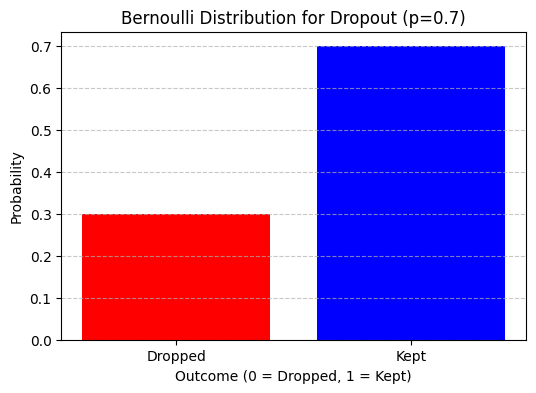

Probability of dropping a neuron (0): 0.30
Probability of keeping a neuron (1): 0.70


In [45]:
import numpy as np
import matplotlib.pyplot as plt

# Define the probability of keeping a neuron (p)
# This is equivalent to 1 - dropout_rate
p = 0.7 # For example, 70% chance of keeping the neuron, 30% dropout rate

# Define the possible outcomes (0 for dropped, 1 for kept)
outcomes = [0, 1]

# Calculate the probabilities for each outcome using the Bernoulli PMF
probability_dropped = 1 - p
probability_kept = p

probabilities = [probability_dropped, probability_kept]

# Create the bar plot
plt.figure(figsize=(6, 4))
plt.bar(outcomes, probabilities, color=['red', 'blue'])

# Add labels and title
plt.title(f'Bernoulli Distribution for Dropout (p={p})')
plt.xlabel('Outcome (0 = Dropped, 1 = Kept)')
plt.ylabel('Probability')
plt.xticks(outcomes, ['Dropped', 'Kept']) # Label the x-axis ticks
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()

print(f"Probability of dropping a neuron (0): {probability_dropped:.2f}")
print(f"Probability of keeping a neuron (1): {probability_kept:.2f}")
